In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage
import skfuzzy as fuzz

# Load dataset
df = pd.read_csv('data/final_cleaned.csv')
df['Social_Responsiveness_Scale'] = df['Social_Responsiveness_Scale'].fillna(df['Social_Responsiveness_Scale'].mean())
X = df.drop(columns=['ASD_traits'])
y = df['ASD_traits']

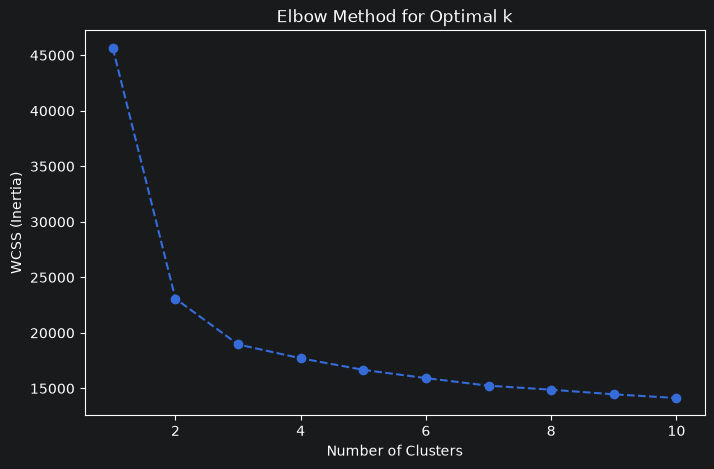

In [2]:
# Scale features
scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(X)

# Elbow Method to find optimal K
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans_tmp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_tmp.fit(X_scaled)
    wcss.append(kmeans_tmp.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

------------------------------
CLUSTERING RESULTS - Full Dataset
------------------------------
Cluster       0    1
Actual ASD          
0.0         326  585
1.0         728  346

Silhouette Score: 0.4538


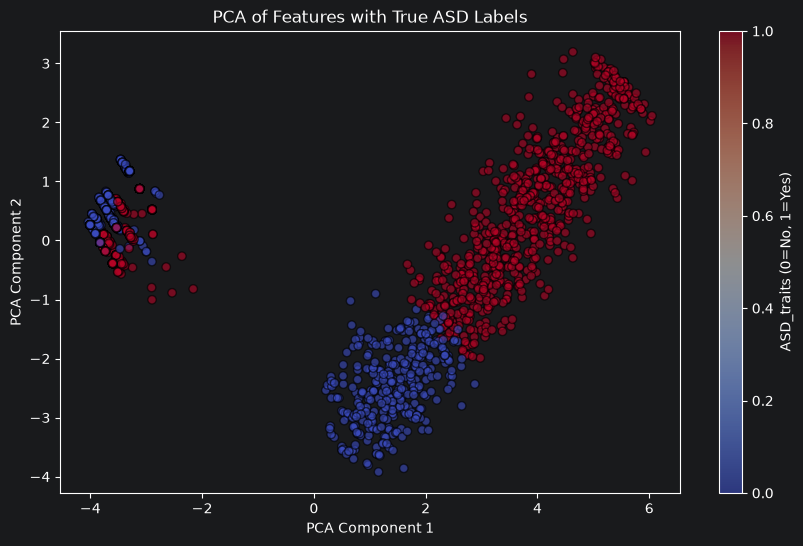

In [3]:
# Fit K-Means with K=2
kmeans_model = KMeans(n_clusters=2, init='k-means++', random_state=42)
clusters = kmeans_model.fit_predict(X_scaled)

# Evaluate full dataset
print("-" * 30)
print("CLUSTERING RESULTS - Full Dataset")
print("-" * 30)
crosstab = pd.crosstab(y, clusters, rownames=['Actual ASD'], colnames=['Cluster'])
print(crosstab)
print(f"\nSilhouette Score: {silhouette_score(X_scaled, clusters):.4f}")

# PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=y,
    cmap='coolwarm',
    alpha=0.6,
    edgecolor='k'
)
plt.title("PCA of Features with True ASD Labels")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='ASD_traits (0=No, 1=Yes)')
plt.show()


=== K-Means Silhouette Scores on Subsets ===
Subset 1: 0.4566
Subset 2: 0.4506


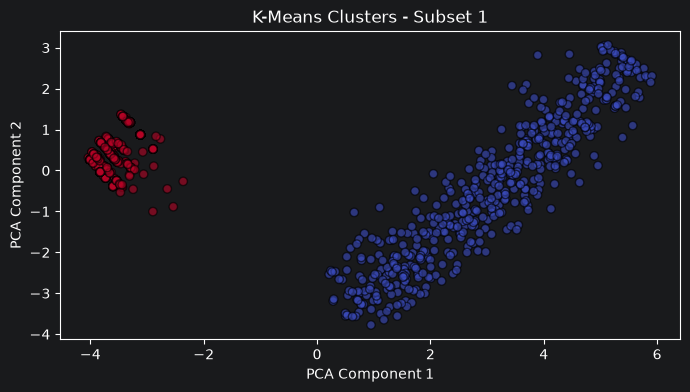

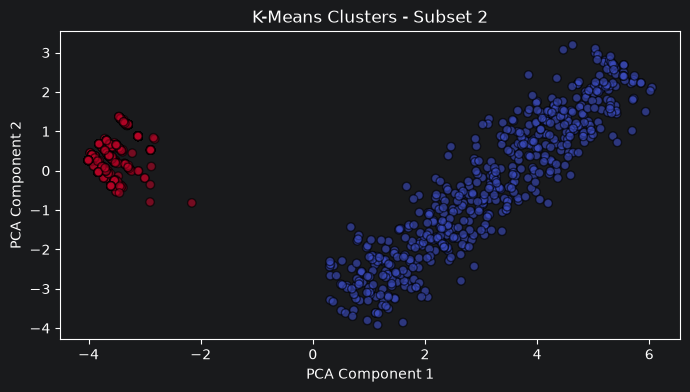

In [4]:
# TESTING ON 2 NEW DATASETS FOR K MEANS
X_test1_scaled, X_test2_scaled = train_test_split(X_scaled, test_size=0.5, random_state=42)

clusters_test1 = kmeans_model.predict(X_test1_scaled)
clusters_test2 = kmeans_model.predict(X_test2_scaled)

score1 = silhouette_score(X_test1_scaled, clusters_test1)
score2 = silhouette_score(X_test2_scaled, clusters_test2)

print("\n=== K-Means Silhouette Scores on Subsets ===")
print(f"Subset 1: {score1:.4f}")
print(f"Subset 2: {score2:.4f}")

# Optional PCA for subsets
X_test1_pca = pca.transform(X_test1_scaled)
X_test2_pca = pca.transform(X_test2_scaled)

plt.figure(figsize=(8,4))
plt.scatter(X_test1_pca[:,0], X_test1_pca[:,1], c=clusters_test1, cmap='coolwarm', alpha=0.6, edgecolor='k')
plt.title("K-Means Clusters - Subset 1")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(X_test2_pca[:,0], X_test2_pca[:,1], c=clusters_test2, cmap='coolwarm', alpha=0.6, edgecolor='k')
plt.title("K-Means Clusters - Subset 2")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [5]:
# Initialize Agglomerative Clustering
agg_model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='average')

# Fit on full scaled data
clusters = agg_model.fit_predict(X_scaled)

# Silhouette score
sil_score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score (Full Dataset): {sil_score:.4f}")

# Compare clusters with actual labels
crosstab = pd.crosstab(y, clusters, rownames=['Actual ASD'], colnames=['Cluster'])
print("\nAgglomerative Clustering vs Actual ASD")
print(crosstab)

Silhouette Score (Full Dataset): 0.4538

Agglomerative Clustering vs Actual ASD
Cluster       0    1
Actual ASD          
0.0         326  585
1.0         728  346


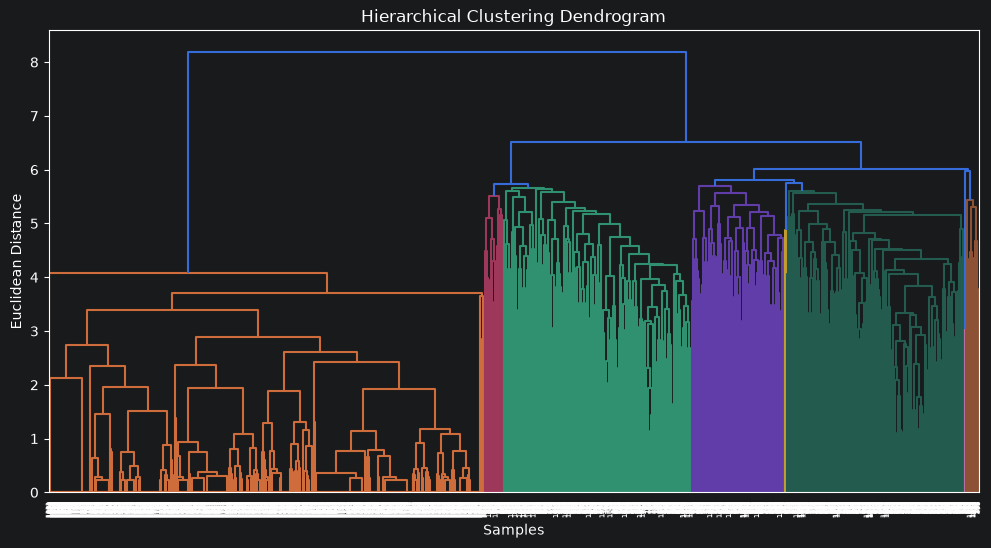

In [6]:
# Dendrogram (Hierarchical Structure)
linked = linkage(X_scaled, method='average')

plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='ascending', show_leaf_counts=False)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()

In [7]:
# 80/20 train-test split for upcoming metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Transpose for scikit-fuzzy
X_train_T = X_train_scaled.T
X_test_T = X_test_scaled.T

# Fuzziness parameter
m = 1.7

# Train the fuzzy model first to get cluster centers (cntr)
cntr, u_train, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_train_T, c=2, m=m, error=0.005, maxiter=1000, init=None, seed=42
)

# Hard cluster labels (train & test)
fuzzy_train_labels = np.argmax(u_train, axis=0)

fuzzy_test_labels = np.argmax(
    fuzz.cluster.cmeans_predict(X_test_T, cntr, m=m, error=0.005, maxiter=1000)[0],
    axis=0
)

# Silhouette Score
train_score = silhouette_score(X_train_scaled, fuzzy_train_labels)
test_score = silhouette_score(X_test_scaled, fuzzy_test_labels)

print(f"Fuzzy C-Means Silhouette Score - Train: {train_score:.4f}")
print(f"Fuzzy C-Means Silhouette Score - Test:  {test_score:.4f}")

Fuzzy C-Means Silhouette Score - Train: 0.4527
Fuzzy C-Means Silhouette Score - Test:  0.4562


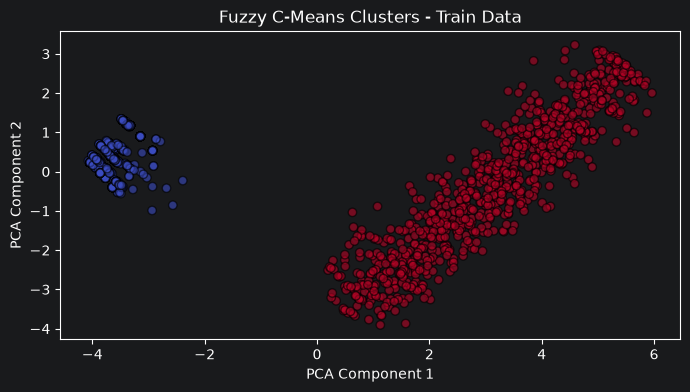

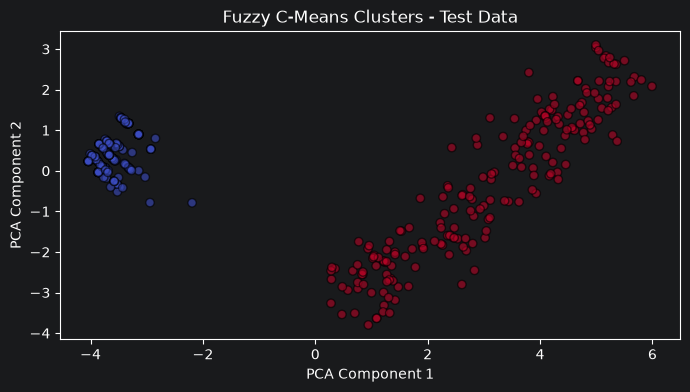

In [8]:
# Reduce to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(8,4))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=fuzzy_train_labels, cmap='coolwarm', alpha=0.6, edgecolor='k')
plt.title("Fuzzy C-Means Clusters - Train Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=fuzzy_test_labels, cmap='coolwarm', alpha=0.6, edgecolor='k')
plt.title("Fuzzy C-Means Clusters - Test Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [9]:
crosstab_train = pd.crosstab(y_train, fuzzy_train_labels, rownames=['Actual ASD'], colnames=['Cluster'])
crosstab_test = pd.crosstab(y_test, fuzzy_test_labels, rownames=['Actual ASD'], colnames=['Cluster'])

print("\nFuzzy C-Means vs Actual ASD - Train")
print(crosstab_train)
print("\nFuzzy C-Means vs Actual ASD - Test")
print(crosstab_test)


Fuzzy C-Means vs Actual ASD - Train
Cluster       0    1
Actual ASD          
0.0         459  256
1.0         278  595

Fuzzy C-Means vs Actual ASD - Test
Cluster       0    1
Actual ASD          
0.0         126   70
1.0          68  133


In [10]:
# Helper function to compute metrics for clustering
def clustering_metrics(y_true, cluster_labels):
    # Check for label flip
    acc_normal = accuracy_score(y_true, cluster_labels)
    acc_flipped = accuracy_score(y_true, 1 - cluster_labels)
    if acc_flipped > acc_normal:
        cluster_labels = 1 - cluster_labels  # flip labels

    # Return all metrics
    return {
        "Accuracy": accuracy_score(y_true, cluster_labels),
        "Precision": precision_score(y_true, cluster_labels),
        "Recall": recall_score(y_true, cluster_labels),
        "F1 Score": f1_score(y_true, cluster_labels)
    }

# We need to run Agglomerative on train/test sets to use the metrics block properly
agg_model_train = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='average')
agg_clusters_train = agg_model_train.fit_predict(X_train_scaled)

agg_model_test = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='average')
agg_clusters_test = agg_model_test.fit_predict(X_test_scaled)

# Hierarchical Clustering Metrics
agg_train_metrics = clustering_metrics(y_train, agg_clusters_train)
agg_test_metrics  = clustering_metrics(y_test, agg_clusters_test)

print("=== Hierarchical Clustering Metrics ===\n")

print("Train Metrics:")
for metric, value in agg_train_metrics.items():
    print(f"{metric}: {value:.2%}")

print("\nTest Metrics:")
for metric, value in agg_test_metrics.items():
    print(f"{metric}: {value:.2%}")

# Fuzzy C-Means Metrics
fuzzy_train_metrics = clustering_metrics(y_train, fuzzy_train_labels)
fuzzy_test_metrics  = clustering_metrics(y_test, fuzzy_test_labels)

print("\n=== Fuzzy C-Means Metrics ===\n")

print("Train Metrics:")
for metric, value in fuzzy_train_metrics.items():
    print(f"{metric}: {value:.2%}")

print("\nTest Metrics:")
for metric, value in fuzzy_test_metrics.items():
    print(f"{metric}: {value:.2%}")

=== Hierarchical Clustering Metrics ===

Train Metrics:
Accuracy: 66.37%
Precision: 69.92%
Recall: 68.16%
F1 Score: 69.03%

Test Metrics:
Accuracy: 65.24%
Precision: 65.52%
Recall: 66.17%
F1 Score: 65.84%

=== Fuzzy C-Means Metrics ===

Train Metrics:
Accuracy: 66.37%
Precision: 69.92%
Recall: 68.16%
F1 Score: 69.03%

Test Metrics:
Accuracy: 65.24%
Precision: 65.52%
Recall: 66.17%
F1 Score: 65.84%


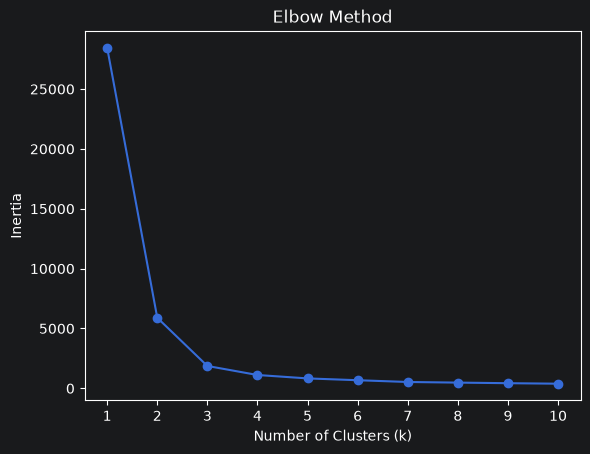

=== Elbow Method Result ===
Suggested number of clusters (k): 2


In [11]:
# FINDING OPTIMAL K
from sklearn.mixture import GaussianMixture
from sklearn.metrics import classification_report

# Split into two subsets
X_full = X_pca
X_part1, X_part2, y_part1, y_part2 = train_test_split(
    X_pca, y, test_size=0.5, random_state=42
)

# Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)

# Plot Elbow
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.show()

# Compute approximate elbow via second derivative
diff1 = np.diff(inertia)
diff2 = np.diff(diff1)
elbow_k = np.argmax(diff2) + 2  # +2 because diff shifts index

print("=== Elbow Method Result ===")
print(f"Suggested number of clusters (k): {elbow_k}")

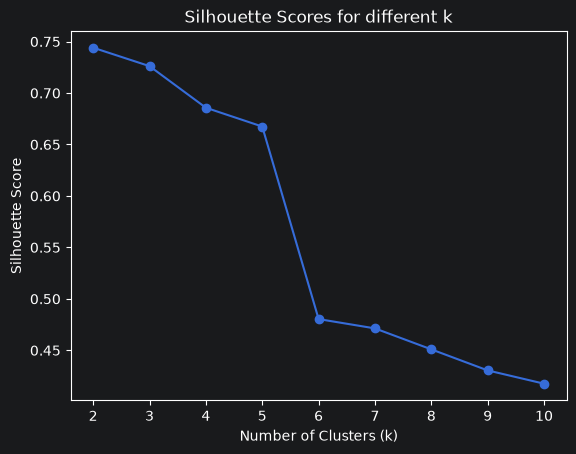


=== Silhouette Method Result ===
k = 2 → Silhouette Score = 0.7440
k = 3 → Silhouette Score = 0.7261
k = 4 → Silhouette Score = 0.6857
k = 5 → Silhouette Score = 0.6674
k = 6 → Silhouette Score = 0.4804
k = 7 → Silhouette Score = 0.4713
k = 8 → Silhouette Score = 0.4509
k = 9 → Silhouette Score = 0.4305
k = 10 → Silhouette Score = 0.4176

Best k according to Silhouette Score: 2

=== FINAL RECOMMENDATION ===
Both methods agree → Use k = 2


In [12]:
# Silhouette Method
sil_scores = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    sil_scores[k] = silhouette_score(X_pca, labels)

# Plot Silhouette Scores
plt.figure()
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.title("Silhouette Scores for different k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.show()

best_sil_k = max(sil_scores, key=sil_scores.get)

print("\n=== Silhouette Method Result ===")
for k, score in sil_scores.items():
    print(f"k = {k} → Silhouette Score = {score:.4f}")

print(f"\nBest k according to Silhouette Score: {best_sil_k}")

# Final Recommendation
print("\n=== FINAL RECOMMENDATION ===")
if elbow_k == best_sil_k:
    print(f"Both methods agree → Use k = {elbow_k}")
else:
    print(f"Elbow suggests k = {elbow_k}")
    print(f"Silhouette suggests k = {best_sil_k}")
    print("Recommended to try both and compare cluster stability.")

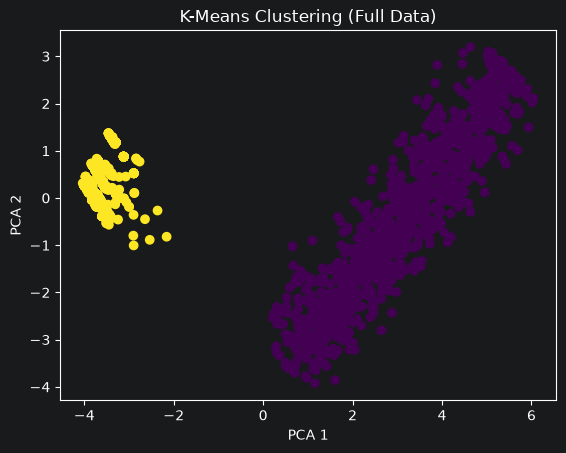

=== K-Means Full Data ===
              precision    recall  f1-score   support

         0.0       0.31      0.36      0.33       911
         1.0       0.37      0.32      0.35      1074

    accuracy                           0.34      1985
   macro avg       0.34      0.34      0.34      1985
weighted avg       0.34      0.34      0.34      1985



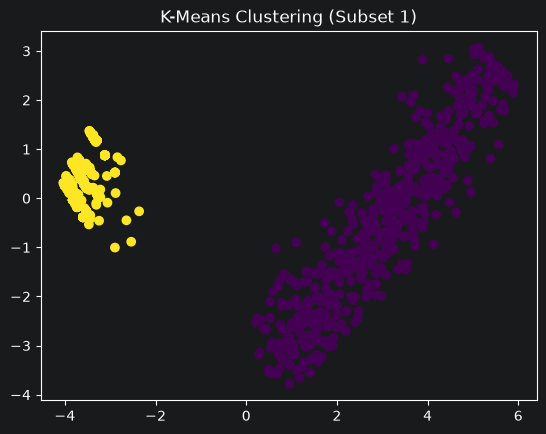

=== K-Means Subset 1 ===
              precision    recall  f1-score   support

         0.0       0.30      0.35      0.32       454
         1.0       0.37      0.33      0.35       538

    accuracy                           0.34       992
   macro avg       0.34      0.34      0.34       992
weighted avg       0.34      0.34      0.34       992



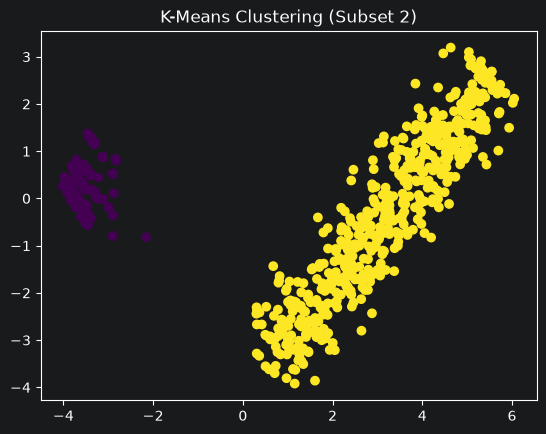

=== K-Means Subset 2 ===
              precision    recall  f1-score   support

         0.0       0.63      0.63      0.63       457
         1.0       0.69      0.68      0.69       536

    accuracy                           0.66       993
   macro avg       0.66      0.66      0.66       993
weighted avg       0.66      0.66      0.66       993



In [13]:
# K-MEANS CLUSTERING
kmeans_full = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_full = kmeans_full.fit_predict(X_full)

plt.figure()
plt.scatter(X_full[:,0], X_full[:,1], c=labels_full)
plt.title("K-Means Clustering (Full Data)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

print("=== K-Means Full Data ===")
print(classification_report(y, labels_full))

# K-Means for subset 1
kmeans_p1 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_p1 = kmeans_p1.fit_predict(X_part1)

plt.figure()
plt.scatter(X_part1[:,0], X_part1[:,1], c=labels_p1)
plt.title("K-Means Clustering (Subset 1)")
plt.show()

print("=== K-Means Subset 1 ===")
print(classification_report(y_part1, labels_p1))

# K-Means for subset 2
kmeans_p2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_p2 = kmeans_p2.fit_predict(X_part2)

plt.figure()
plt.scatter(X_part2[:,0], X_part2[:,1], c=labels_p2)
plt.title("K-Means Clustering (Subset 2)")
plt.show()

print("=== K-Means Subset 2 ===")
print(classification_report(y_part2, labels_p2))

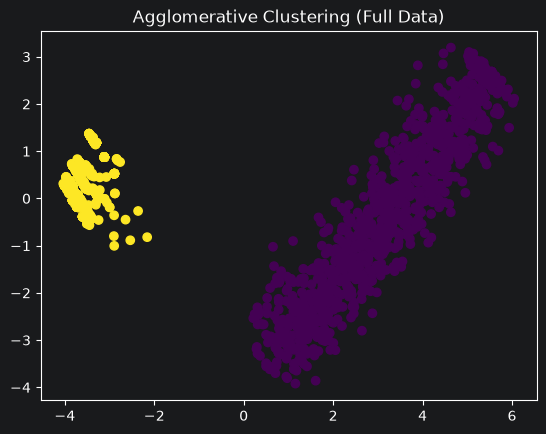

=== Agglomerative Full Data ===
              precision    recall  f1-score   support

         0.0       0.31      0.36      0.33       911
         1.0       0.37      0.32      0.35      1074

    accuracy                           0.34      1985
   macro avg       0.34      0.34      0.34      1985
weighted avg       0.34      0.34      0.34      1985



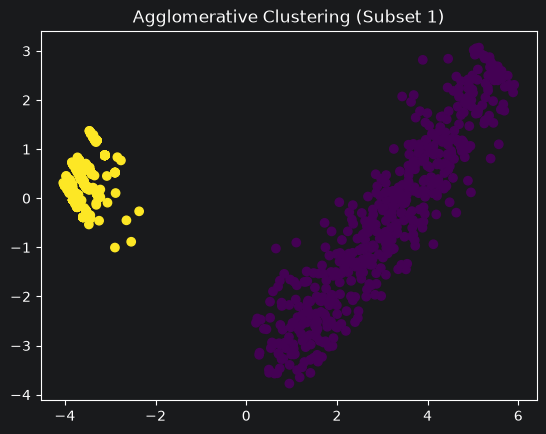

=== Agglomerative Subset 1 ===
              precision    recall  f1-score   support

         0.0       0.30      0.35      0.32       454
         1.0       0.37      0.33      0.35       538

    accuracy                           0.34       992
   macro avg       0.34      0.34      0.34       992
weighted avg       0.34      0.34      0.34       992



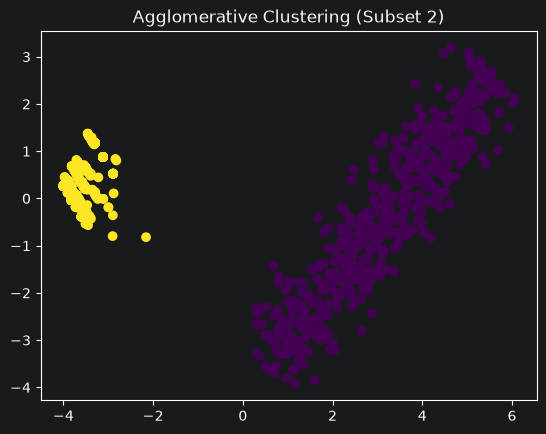

=== Agglomerative Subset 2 ===
              precision    recall  f1-score   support

         0.0       0.31      0.37      0.34       457
         1.0       0.37      0.32      0.34       536

    accuracy                           0.34       993
   macro avg       0.34      0.34      0.34       993
weighted avg       0.34      0.34      0.34       993



In [14]:
# HIERARCHICAL CLUSTERING
# Agglomerative (Bottom-Up)
agg_full = AgglomerativeClustering(n_clusters=2).fit_predict(X_full)
plt.figure()
plt.scatter(X_full[:,0], X_full[:,1], c=agg_full)
plt.title("Agglomerative Clustering (Full Data)")
plt.show()
print("=== Agglomerative Full Data ===")
print(classification_report(y, agg_full))

# Agglomerative Subset 1
agg_p1 = AgglomerativeClustering(n_clusters=2).fit_predict(X_part1)
plt.figure()
plt.scatter(X_part1[:,0], X_part1[:,1], c=agg_p1)
plt.title("Agglomerative Clustering (Subset 1)")
plt.show()
print("=== Agglomerative Subset 1 ===")
print(classification_report(y_part1, agg_p1))

# Agglomerative Subset 2
agg_p2 = AgglomerativeClustering(n_clusters=2).fit_predict(X_part2)
plt.figure()
plt.scatter(X_part2[:,0], X_part2[:,1], c=agg_p2)
plt.title("Agglomerative Clustering (Subset 2)")
plt.show()
print("=== Agglomerative Subset 2 ===")
print(classification_report(y_part2, agg_p2))

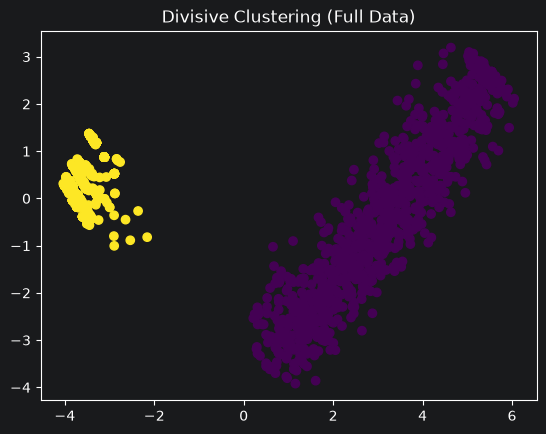

=== Divisive Full Data ===
              precision    recall  f1-score   support

         0.0       0.31      0.36      0.33       911
         1.0       0.37      0.32      0.35      1074

    accuracy                           0.34      1985
   macro avg       0.34      0.34      0.34      1985
weighted avg       0.34      0.34      0.34      1985



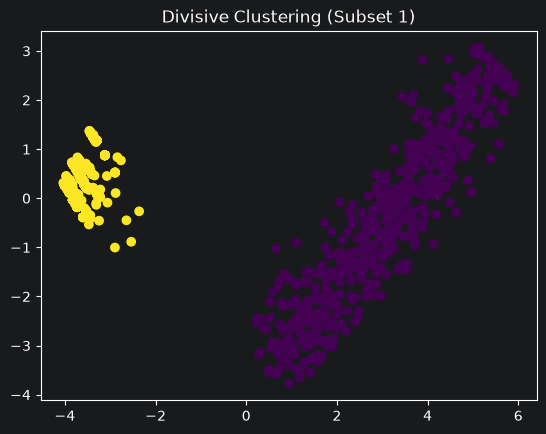

=== Divisive Subset 1 ===
              precision    recall  f1-score   support

         0.0       0.30      0.35      0.32       454
         1.0       0.37      0.33      0.35       538

    accuracy                           0.34       992
   macro avg       0.34      0.34      0.34       992
weighted avg       0.34      0.34      0.34       992



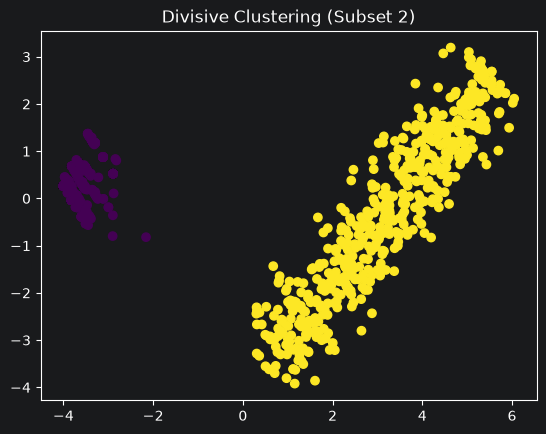

=== Divisive Subset 2 ===
              precision    recall  f1-score   support

         0.0       0.63      0.63      0.63       457
         1.0       0.69      0.68      0.69       536

    accuracy                           0.66       993
   macro avg       0.66      0.66      0.66       993
weighted avg       0.66      0.66      0.66       993



In [15]:
# Divisive
div_full = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_full)
plt.figure()
plt.scatter(X_full[:,0], X_full[:,1], c=div_full)
plt.title("Divisive Clustering (Full Data)")
plt.show()
print("=== Divisive Full Data ===")
print(classification_report(y, div_full))

# Divisive Subset 1
div_p1 = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_part1)
plt.figure()
plt.scatter(X_part1[:,0], X_part1[:,1], c=div_p1)
plt.title("Divisive Clustering (Subset 1)")
plt.show()
print("=== Divisive Subset 1 ===")
print(classification_report(y_part1, div_p1))

# Divisive Subset 2
div_p2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_part2)
plt.figure()
plt.scatter(X_part2[:,0], X_part2[:,1], c=div_p2)
plt.title("Divisive Clustering (Subset 2)")
plt.show()
print("=== Divisive Subset 2 ===")
print(classification_report(y_part2, div_p2))

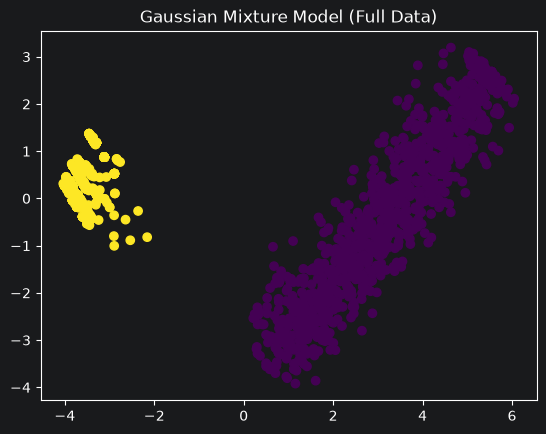

=== GMM Full Data ===
              precision    recall  f1-score   support

         0.0       0.31      0.36      0.33       911
         1.0       0.37      0.32      0.35      1074

    accuracy                           0.34      1985
   macro avg       0.34      0.34      0.34      1985
weighted avg       0.34      0.34      0.34      1985



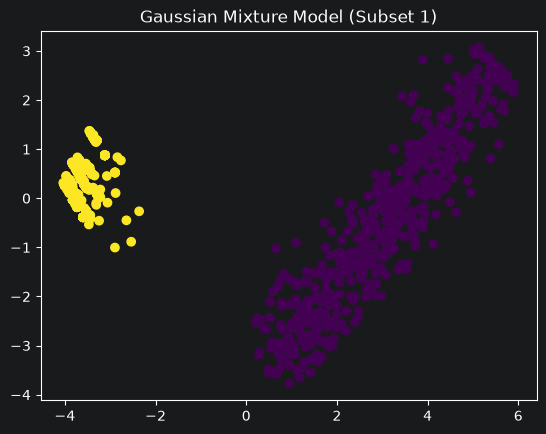

=== GMM Subset 1 ===
              precision    recall  f1-score   support

         0.0       0.30      0.35      0.32       454
         1.0       0.37      0.33      0.35       538

    accuracy                           0.34       992
   macro avg       0.34      0.34      0.34       992
weighted avg       0.34      0.34      0.34       992



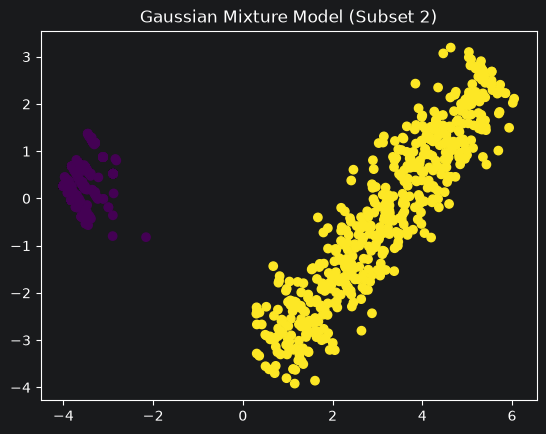

=== GMM Subset 2 ===
              precision    recall  f1-score   support

         0.0       0.63      0.63      0.63       457
         1.0       0.69      0.68      0.69       536

    accuracy                           0.66       993
   macro avg       0.66      0.66      0.66       993
weighted avg       0.66      0.66      0.66       993



In [16]:
# GAUSSIAN MIXTURE MODEL
from sklearn.mixture import GaussianMixture
gmm_full = GaussianMixture(n_components=2, random_state=42).fit_predict(X_full)
plt.figure()
plt.scatter(X_full[:,0], X_full[:,1], c=gmm_full)
plt.title("Gaussian Mixture Model (Full Data)")
plt.show()
print("=== GMM Full Data ===")
print(classification_report(y, gmm_full))

# GMM Subset 1
gmm_p1 = GaussianMixture(n_components=2, random_state=42).fit_predict(X_part1)
plt.figure()
plt.scatter(X_part1[:,0], X_part1[:,1], c=gmm_p1)
plt.title("Gaussian Mixture Model (Subset 1)")
plt.show()
print("=== GMM Subset 1 ===")
print(classification_report(y_part1, gmm_p1))

# GMM Subset 2
gmm_p2 = GaussianMixture(n_components=2, random_state=42).fit_predict(X_part2)
plt.figure()
plt.scatter(X_part2[:,0], X_part2[:,1], c=gmm_p2)
plt.title("Gaussian Mixture Model (Subset 2)")
plt.show()
print("=== GMM Subset 2 ===")
print(classification_report(y_part2, gmm_p2))


=== K=3 CLUSTERING & LABEL MAPPING (FULL DATA) ===

--- K-Means (Mapped Labels) ---
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       911
           1       1.00      0.51      0.67      1074

    accuracy                           0.73      1985
   macro avg       0.82      0.75      0.72      1985
weighted avg       0.83      0.73      0.72      1985


--- Agglomerative (Mapped Labels) ---
              precision    recall  f1-score   support

           0       0.63      0.64      0.64       911
           1       0.69      0.68      0.68      1074

    accuracy                           0.66      1985
   macro avg       0.66      0.66      0.66      1985
weighted avg       0.66      0.66      0.66      1985


--- Divisive (Approx) (Mapped Labels) ---
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       911
           1       1.00      0.51      0.67      1074

    accuracy   

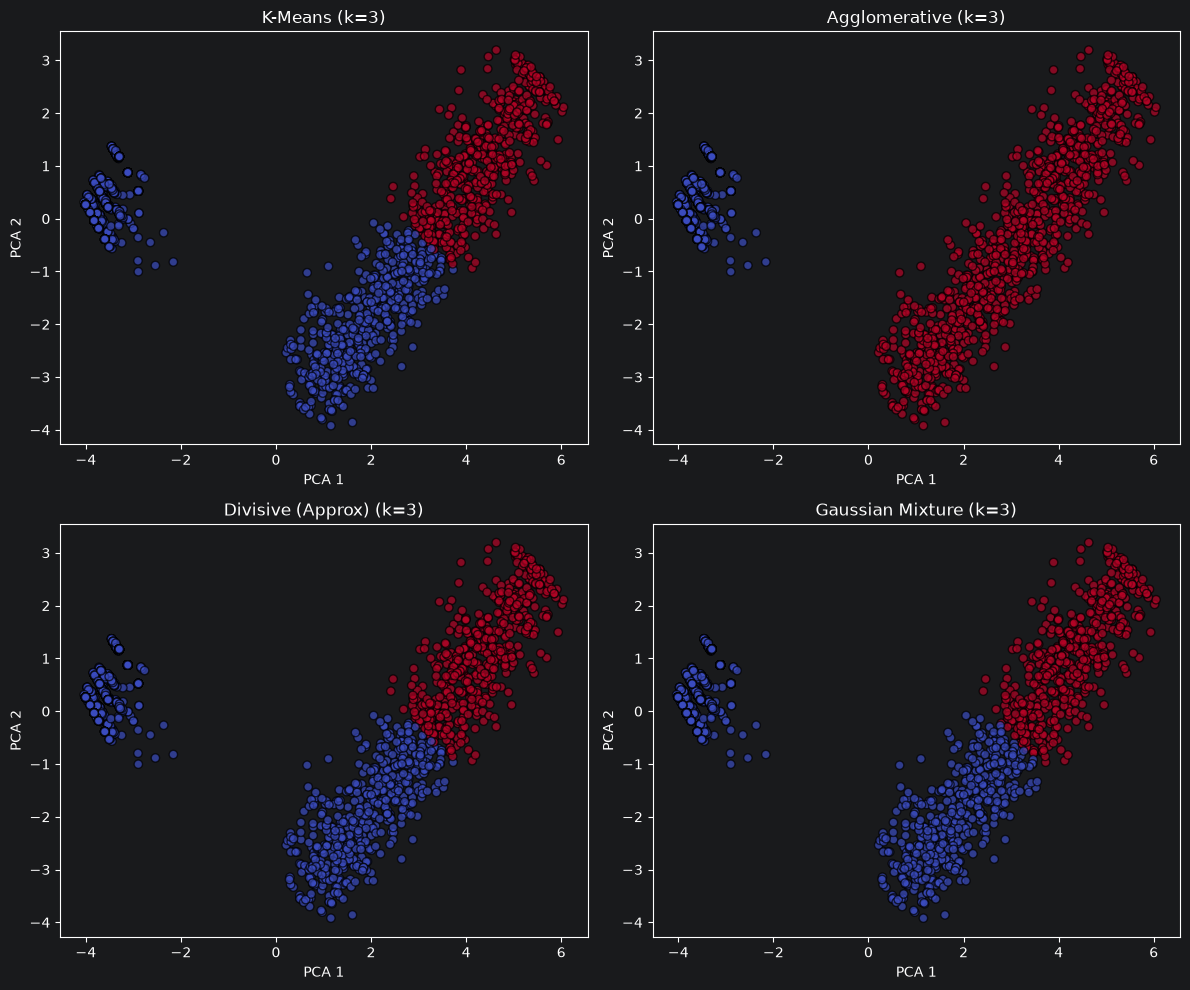

In [17]:
# Checking with k=3 instead of k=2
# Function to map k=3 clusters to binary true labels based on majority vote
def map_clusters_to_labels(y_true, y_clusters):
    y_true = y_true.astype(int)
    mapping = {}
    for cluster in np.unique(y_clusters):
        indices = np.where(y_clusters == cluster)[0]
        # Find the most common true label in this cluster
        most_common = np.bincount(y_true[indices]).argmax()
        mapping[cluster] = most_common
    return np.array([mapping[c] for c in y_clusters])

print("\n=== K=3 CLUSTERING & LABEL MAPPING (FULL DATA) ===")

models_k3 = {
    "K-Means": KMeans(n_clusters=3, random_state=42, n_init=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=3),
    "Divisive (Approx)": KMeans(n_clusters=3, random_state=42, n_init=10),
    "Gaussian Mixture": GaussianMixture(n_components=3, random_state=42)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (name, model) in enumerate(models_k3.items()):
    # Fit and map labels
    labels = model.fit_predict(X_pca)
    mapped_labels = map_clusters_to_labels(y, labels)

    # Plotting
    scatter = axes[i].scatter(
        X_pca[:,0], X_pca[:,1],
        c=mapped_labels, cmap="coolwarm", alpha=0.7, edgecolor='k'
    )
    axes[i].set_title(f"{name} (k=3)")
    axes[i].set_xlabel("PCA 1")
    axes[i].set_ylabel("PCA 2")

    # Print report
    print(f"\n--- {name} (Mapped Labels) ---")
    print(classification_report(y.astype(int), mapped_labels))

plt.tight_layout()
plt.show()

In [18]:
# Finding the best performing unsupervised model
# Helper function to align unsupervised cluster labels with true binary labels
def get_best_aligned_labels(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    # Check regular vs flipped accuracy
    acc_direct = accuracy_score(y_true, y_pred)
    acc_flipped = accuracy_score(y_true, 1 - y_pred)

    if acc_flipped > acc_direct:
        return 1 - y_pred
    return y_pred

# Collect predictions from all models (using Full Data / Test partitions where applicable)
evaluation_candidates = {}

# K-Means (k=2)
km_pred = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_full)
evaluation_candidates["K-Means (k=2)"] = get_best_aligned_labels(y, km_pred)

# Agglomerative (k=2)
agg_pred = AgglomerativeClustering(n_clusters=2).fit_predict(X_full)
evaluation_candidates["Agglomerative (k=2)"] = get_best_aligned_labels(y, agg_pred)

# Divisive / Top-Down Approx (k=2)
div_pred = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_full)
evaluation_candidates["Divisive Approx (k=2)"] = get_best_aligned_labels(y, div_pred)

# GMM (k=2)
gmm_pred = GaussianMixture(n_components=2, random_state=42).fit_predict(X_full)
evaluation_candidates["Gaussian Mixture (k=2)"] = get_best_aligned_labels(y, gmm_pred)

# Fuzzy C-Means (Test Set predictions if available, else Full)
try:
    fcm_pred = get_best_aligned_labels(y_test, fuzzy_test_labels)
    evaluation_candidates["Fuzzy C-Means (Test Set)"] = fcm_pred
except NameError:
    pass

# Evaluate and find the best model
results_summary = []

print(f"{'Model Name':<32} | {'Accuracy':<10} | {'F1-Score':<10}")
print("-" * 55)

for name, preds in evaluation_candidates.items():
    target_y = y_test if "Test Set" in name else y

    acc = accuracy_score(target_y, preds)
    f1 = f1_score(target_y, preds, zero_division=0)

    results_summary.append({"name": name, "accuracy": acc, "f1": f1})
    print(f"{name:<30} | {acc*100:6.2f}%    | {f1:6.4f}")

# Determine the absolute winner based on Accuracy (and fallback to F1)
best_model = max(results_summary, key=lambda x: (x["accuracy"], x["f1"]))

print(f"\nBEST PERFORMING UNSUPERVISED MODEL:")
print(f"-> {best_model['name']} predicted the most correctly with an Accuracy of {best_model['accuracy']*100:.2f}% and an F1-Score of {best_model['f1']:.4f}.\n")

Model Name                       | Accuracy   | F1-Score  
-------------------------------------------------------
K-Means (k=2)                  |  66.15%    | 0.6842
Agglomerative (k=2)            |  66.15%    | 0.6842
Divisive Approx (k=2)          |  66.15%    | 0.6842
Gaussian Mixture (k=2)         |  66.15%    | 0.6842
Fuzzy C-Means (Test Set)       |  65.24%    | 0.6584

BEST PERFORMING UNSUPERVISED MODEL:
-> K-Means (k=2) predicted the most correctly with an Accuracy of 66.15% and an F1-Score of 0.6842.



In [22]:
import joblib

# K-MEANS
joblib.dump(kmeans_full, "unsupervised_models/kmeans.pkl")

# GAUSSIAN MIXTURE MODEL (GMM)
gmm_model = GaussianMixture(n_components=2, random_state=42)
gmm_model.fit(X_full)
joblib.dump(gmm_model, "unsupervised_models/gmm.pkl")

# DIVISIVE CLUSTERING (K-Means)
div_model = KMeans(n_clusters=2, random_state=42, n_init=10)
div_model.fit(X_full)
joblib.dump(div_model, "unsupervised_models/divisive_kmeans.pkl")

# PCA
joblib.dump(pca, "unsupervised_models/pca.pkl")

['unsupervised_models/pca.pkl']